In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self,in_c,out_c):
        super().__init__()
        self.c1=nn.Conv2d(in_c,out_c,3,padding=0,bias=True)
        self.c2=nn.Conv2d(out_c,out_c,3,padding=0,bias=True)
        self.r=nn.ReLU(inplace=True)
    def forward(self,x):
        x=self.c1(x)
        x=self.c2(x)
        out=self.r(x)
        return out
    
class Down(nn.Module):
    def __init__(self,in_c,out_c):
        super().__init__()
        self.pool=nn.MaxPool2d(2)
        self.block=DoubleConv(in_c,out_c)
    def forward(self,x):
        x=self.pool(x)
        out=self.block(x)
        return out
        
class UP(nn.Module):
    def __init__(self,in_c,out_c):
        super().__init__()
        self.up=nn.ConvTranspose2d(in_c,in_c//2,2,stride=2)
        self.block=DoubleConv(in_c,out_c)
    def forward(self,x,skip):
        x=self.up(x)
        th,tw=x.shape[-2:]
        Hs,Ws=skip.shape[-2:]
        dh,dw=(Hs-th)//2,(Ws-tw)//2
        skip_c=skip[...,dh:dh+th,dw:dw+tw]
        x=torch.cat([skip_c,x],dim=1)
        out=self.block(x)
        return out

class UNet(nn.Module):
    def __init__(self,in_c=3,n_classes=1,base=64):
        super().__init__()
        self.inc=DoubleConv(in_c,base)
        self.down1=Down(base,base*2)
        self.down2=Down(base*2,base*4)
        self.down3=Down(base*4,base*8)
        self.down4=Down(base*8,base*16)
        self.up1=UP(base*16,base*8)
        self.up2=UP(base*8,base*4)
        self.up3=UP(base*4,base*2)
        self.up4=UP(base*2,base)
        self.outc=nn.Conv2d(base,n_classes,1)

    def forward(self,x):
        #인코딩층
        x1=self.inc(x)
        x2=self.down1(x1)
        x3=self.down2(x2)
        x4=self.down3(x3)
        x5=self.down4(x4)

        #디코더층
        x=self.up1(x5,x4)
        x=self.up2(x,x3)
        x=self.up3(x,x2)
        x=self.up4(x,x1)

        #출력층
        out=self.outc(x)
        return out

In [2]:
#작업 준비
import os, time
from pathlib import Path
import numpy as np
from PIL import Image

from torch.utils.data import Dataset,DataLoader
from torchvision.transforms import functional as TF

import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

#상수정의
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_WORERS=4
DATA_ROOT='./data/VOCdevkit'
SPLIT='VOC2012'
BATCH_SIZE=8
EPOCHS=5
LR=0.005
MOMENTUM=0.9
WEIGHT_DECAY=0.0001

IMG_SIZE=512
N_CLASSES=21
IGNORE_INDEX=255

OUT_DIR='runs/fcn_scratch'
BEST_PATH=os.path.join(OUT_DIR,'best_m.pth')
os.makedirs(OUT_DIR,exist_ok=True)


In [3]:
#데이터 수집(데이터 로드)
def make_transform(train):
    def _tfm(img,mask):
        img= TF.resize(img,(IMG_SIZE,IMG_SIZE))
        mask= TF.resize(mask,(IMG_SIZE,IMG_SIZE),interpolation=TF.InterpolationMode.NEAREST)
        if train and torch.rand(1)<0.5:
            img = TF.hflip(img)
            mask = TF.hflip(mask)
        img = TF.to_tensor(img)
        img = TF.normalize(img, [0.485,0.456,0.406], [0.229,0.224,0.225])
        mask=torch.as_tensor(np.array(mask),dtype=torch.long)
        return img,mask
    return _tfm
class VOCDatasetTrain(Dataset):
    def __init__(self,root,split,image_set,transforms=None):
        base=Path(root)/split
        self.img_dir=base/'JPEGImages'
        self.mask_dir=base/'SegmentationClass'
        with open(base/'ImageSets'/'Segmentation'/f'{image_set}.txt') as f:
            self.ids= [x.strip() for x in f if x.strip()]
        self.tfm=transforms
    def __len__(self):
        return len(self.ids)
    def __getitem__(self,idx):
        id_ =self.ids[idx]
        img=Image.open(self.img_dir/f'{id_}.jpg').convert('RGB')
        mask=Image.open(self.mask_dir/f'{id_}.png')
        if self.tfm:
            img,mask=self.tfm(img,mask)
        return img,mask

class VOCDatasetVal(VOCDatasetTrain):
    def __getitem__(self,idx):
        id_ =self.ids[idx]
        img=Image.open(self.img_dir/f'{id_}.jpg').convert('RGB')
        mask=Image.open(self.mask_dir/f'{id_}.png')
        if self.tfm:
            img,mask=self.tfm(img,mask)
        return img,mask,id_

def get_loaders():
    tr_ds=VOCDatasetTrain(DATA_ROOT,SPLIT,'train',transforms=make_transform(train=True))
    val_ds=VOCDatasetVal(DATA_ROOT,SPLIT,'val',transforms=make_transform(train=False))
    
    #tr_ds_loader = DataLoader(tr_ds,batch_size=BATCH_SIZE,shuffle=True)
    #val_ds_loader = DataLoader(val_ds,batch_size=BATCH_SIZE,shuffle=False)
    tr_ds_loader = DataLoader(tr_ds,batch_size=BATCH_SIZE,shuffle=True,num_workers=NUM_WORERS, pin_memory=True)
    val_ds_loader = DataLoader(val_ds,batch_size=BATCH_SIZE,shuffle=False,num_workers=NUM_WORERS, pin_memory=True)
    return tr_ds,val_ds,tr_ds_loader,val_ds_loader 

In [4]:
def center_crop(t,size_hw):
    H,W=t.shape[-2:]
    th,tw=size_hw
    dh,dw=(H-th)//2,(W-tw)//2
    return t[...,dh:dh+th,dw:dw+tw]

In [5]:
def fast_hist(pred,label,n_class=21):
    k=(0<=label) & (label<n_class)
    return np.bincount(n_class*label[k].astype(int)+pred[k].astype(int), minlength=n_class**2).reshape(n_class,n_class) 
def miou_from_hist(hist):
    iu = np.diag(hist)/(hist.sum(1)+hist.sum(0)-np.diag(hist)+1e-10)
    return float(np.nanmean(iu)),iu

In [6]:
#색 정립 (배경/무시 정리)

PAL = np.array([
    [0,0,0],[128,0,0],[0,128,0],[128,128,0],[0,0,128],
    [128,0,128],[0,128,128],[128,128,128],[64,0,0],[192,0,0],
    [64,128,0],[192,128,0],[64,0,128],[192,0,128],[64,128,128],
    [192,128,128],[0,64,0],[128,64,0],[0,192,0],[128,192,0],[0,64,128]
], dtype=np.uint8)
BG_COLOR=np.array([50,50,50],dtype=np.uint8)        #배경(0): 어두운 회색
IGNORE_COLOR=np.array([100,100,100],dtype=np.uint8) #무시(255): 밝은 회색

def _denorm(img):
    mean=torch.tensor([0.485, 0.456, 0.406],device=img.device)[:,None,None]
    std=torch.tensor([0.229, 0.224, 0.225],device=img.device)[:,None,None]
    return (img*std+mean).clamp(0,1)
    
def _colorize_mask(mask_np,ignore_idx):
    out=PAL[np.clip(mask_np,0,len(PAL)-1)].copy()
    out[mask_np == 0]=BG_COLOR
    out[mask_np == ignore_idx]=IGNORE_COLOR
    return out

    
@torch.no_grad()
def visualize_val_grid_random(epoch,model,val_ds,device,out_dir=OUT_DIR, samples=4):
    if len(val_ds)==0:
        print("검증 안함")
        return 
    os.makedirs(out_dir,exist_ok=True)
    
    idxs = np.random.choice(len(val_ds),size=min(samples,len(val_ds)),replace=False)
    imgs,gts=[],[]
    for idx in idxs:
        img,mask,_ = val_ds[idx]
        imgs.append(img)
        gts.append(mask)
    batch = torch.stack(imgs).to(device)
    gts_np = [m.numpy() for m in gts]

    model.eval()
    out=model(batch)
    out=out['out'] if isinstance(out, dict) else out
    preds=out.argmax(1).detach().cpu().numpy()

    B=len(idxs)
    f,ax=plt.subplots(B,3,figsize=(12,3*B))

    if B==1:
        ax=np.expand_dims(ax,0)
    for i in range(B):
        img_np   = _denorm(batch[i]).detach().cpu().numpy().transpose(1, 2, 0)
        gt_rgb = _colorize_mask(gts_np[i],IGNORE_INDEX)
        pred_rgb = _colorize_mask(preds[i],IGNORE_INDEX)

        ax[i,0].imshow(img_np)
        ax[i,0].set_title("oj_img")
        ax[i,0].axis('off')
        
        ax[i,1].imshow(gt_rgb)
        ax[i,1].set_title("oj_mask")
        ax[i,1].axis('off')
        
        ax[i,2].imshow(pred_rgb)
        ax[i,2].set_title("pr_mask")
        ax[i,2].axis('off')
    plt.suptitle(f'val_(R)-Epoch{epoch}')
    save_path=os.path.join(out_dir,f'val_Epoch{epoch}.grid.png')
    plt.tight_layout()
    plt.savefig(save_path,dpi=150)
    plt.show()
    plt.close()
    print(f"기록 저장됨{save_path}")

In [7]:
from tqdm import tqdm
def train(model,criterion,opt,scaler,loader,device,epoch):
    model.train()
    run=0.0
    t0=time.time()
    for x,y in tqdm(loader):
        imgs=x.to(device)
        masks=y.to(device)

        opt.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(imgs)
            masks_c=center_crop(masks,logits.shape[-2:])
            loss = criterion(logits,masks_c.long())
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        run+=loss.item()*imgs.size(0)
    avg_loss = run/len(loader.dataset)
    print(f"[Epoch{epoch}] tr_loss:{avg_loss} t:{time.time()-t0}")
    return avg_loss
    
@torch.no_grad()
def evaluate(model,loader,device,epoch):
    model.eval()
    hist = np.zeros((N_CLASSES,N_CLASSES),dtype=np.float64)
    for batch in  tqdm(loader):
        if len(batch) == 3:
            x,y,id_=batch
        else:
            x,y=batch
        imgs=x.to(device)
        masks=y.to(device)

        logits = model(imgs)
        masks_c=center_crop(masks,logits.shape[-2:])
        preds=torch.argmax(logits,dim=1)
        hist+= fast_hist(preds.cpu().numpy(),masks_c.cpu().numpy(),N_CLASSES)
    miou, iu = miou_from_hist(hist)
    print(f'[Epoch{epoch}] mIoU:{miou*100:.2f}%')
    return miou

In [8]:
#데이터 준비
tr_ds,val_ds,tr_ds_loader,val_ds_loader=get_loaders()

In [9]:
#모델 학습
m=UNet(3,N_CLASSES).to(DEVICE)
criterion=nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)
opt=torch.optim.SGD(m.parameters(),lr=LR,momentum=MOMENTUM,weight_decay=WEIGHT_DECAY)
scaler=torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

In [10]:
best_miou=-1.0
for ep in range(1,EPOCHS+1):
    train(m,criterion,opt,scaler,tr_ds_loader,DEVICE,ep)
    
    miou=evaluate(m,val_ds_loader,DEVICE,ep)
    if miou>best_miou:
        best_miou=miou
        torch.save(
            {
                'epoch':ep,
                'model':m.state_dict(),
                'miou':best_miou,
                'config':{'IMG_SIZE':IMG_SIZE,
                          'N_CLASSES':N_CLASSES,
                          "LR":LR,
                          "MOMENTUM":MOMENTUM,
                          "WEIGHT_DECAY":WEIGHT_DECAY
                         }
            },BEST_PATH)
        print(f"best_m mIoU: {best_miou} 저장 진행" )
    

100%|██████████| 183/183 [00:56<00:00,  3.23it/s]


[Epoch1] tr_loss:2.030940459725635 t:56.6960072517395


100%|██████████| 182/182 [01:10<00:00,  2.57it/s]


[Epoch1] mIoU:2.71%
best_m mIoU: 0.027090443416659043 저장 진행


100%|██████████| 183/183 [01:12<00:00,  2.51it/s]


...

[Epoch4] mIoU:2.76%


100%|██████████| 183/183 [01:08<00:00,  2.66it/s]


[Epoch5] tr_loss:1.7904930476282463 t:68.74038505554199


100%|██████████| 182/182 [00:50<00:00,  3.62it/s]


[Epoch5] mIoU:3.06%
best_m mIoU: 0.03060392759869909 저장 진행


# 새종 분류

In [8]:
import requests

file_url = 'https://data.caltech.edu/records/w9d68-gec53/files/segmentations.tgz?download=1'
file_name = 'segmentations.tgz'

print(f"{file_name} 다운로드 시작...")
try:
    r = requests.get(file_url, stream=True)
    r.raise_for_status() # HTTP 오류 발생 시 예외를 일으킴
    with open(file_name, 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192): 
            f.write(chunk)
    print(f"다운로드 완료: {file_name}")
except requests.exceptions.RequestException as e:
    print(f"다운로드 실패: {e}")

segmentations.tgz 다운로드 시작...
다운로드 완료: segmentations.tgz


In [9]:
!tar -xzvf segmentations.tgz
!mv ./segmentations ./data/CUB_200_2011/

segmentations/
segmentations/084.Red_legged_Kittiwake/
segmentations/084.Red_legged_Kittiwake/Red_Legged_Kittiwake_0007_795402.png
segmentations/084.Red_legged_Kittiwake/Red_Legged_Kittiwake_0062_795434.png
segmentations/084.Red_legged_Kittiwake/Red_Legged_Kittiwake_0027_795454.png
segmentations/084.Red_legged_Kittiwake/Red_Legged_Kittiwake_0029_795403.png
segmentations/084.Red_legged_Kittiwake/Red_Legged_Kittiwake_0071_73800.png
segmentations/084.Red_legged_Kittiwake/Red_Legged_Kittiwake_0014_795432.png
segmentations/084.Red_legged_Kittiwake/Red_Legged_Kittiwake_0016_795460.png
segmentations/084.Red_legged_Kittiwake/Red_Legged_Kittiwake_0042_795457.png
segmentations/084.Red_legged_Kittiwake/Red_Legged_Kittiwake_0060_795414.png
segmentations/084.Red_legged_Kittiwake/Red_Legged_Kittiwake_0020_795439.png
segmentations/084.Red_legged_Kittiwake/Red_Legged_Kittiwake_0069_795435.png
segmentations/084.Red_legged_Kittiwake/Red_Legged_Kittiwake_0043_795416.png
segmentations/084.Red_legged_Kitti

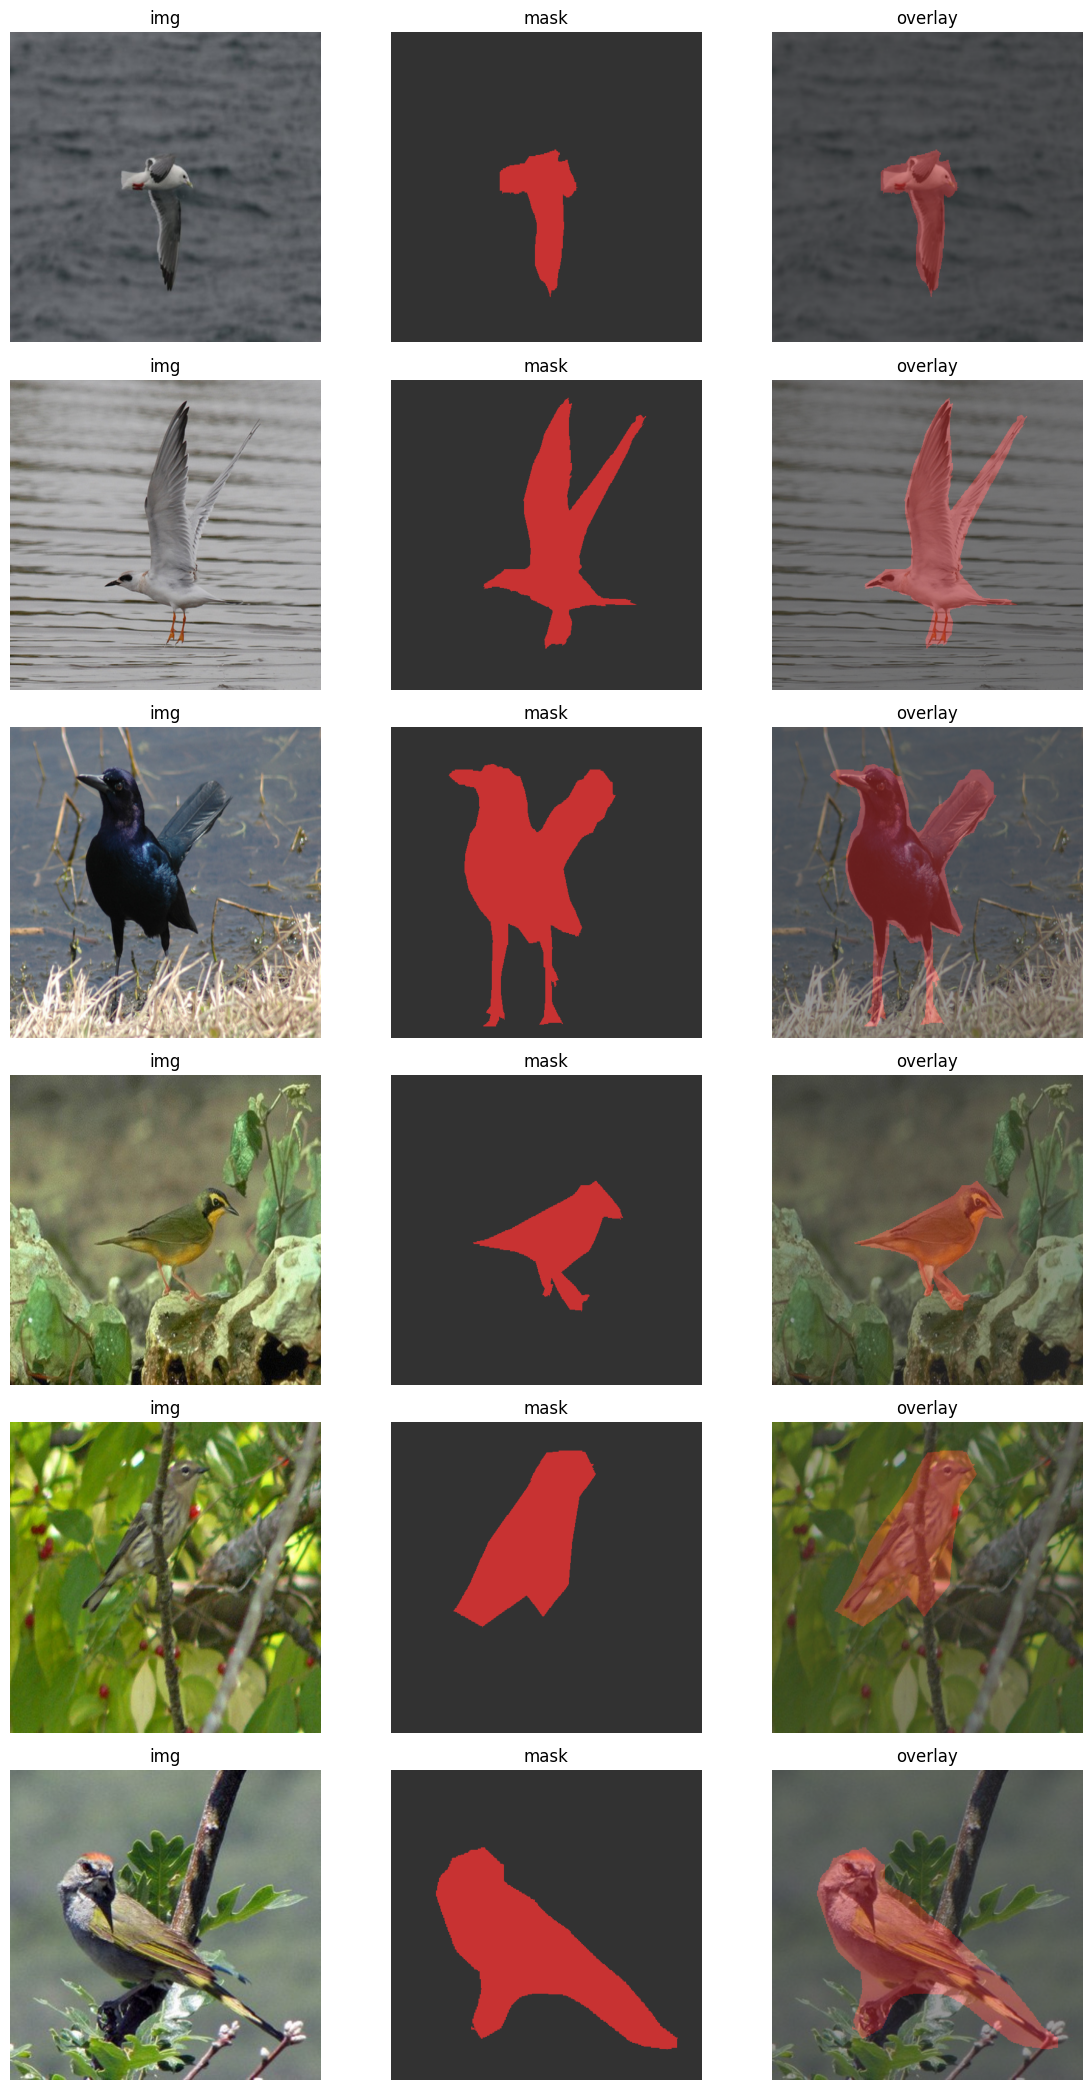

In [10]:
import os
from pathlib import Path
from PIL import Image

import numpy as np

import torch
from torch.utils.data import Dataset,DataLoader
from torchvision.transforms import functional as TF

DATA_ROOT='./data/CUB_200_2011'
BATCH_SIZE=8
NUM_WORERS=4
EPOCHS=5
LR=0.005
MOMENTUM=0.9
WEIGHT_DECAY=0.0001
IMG_SIZE=512
N_CLASSES=2
IGNORE_INDEX=255

def make_transform(train):
    def _tfm(img,mask):
        img= TF.resize(img,(IMG_SIZE,IMG_SIZE))
        mask= TF.resize(mask,(IMG_SIZE,IMG_SIZE),interpolation=TF.InterpolationMode.NEAREST)
        if train and torch.rand(1)<0.5:
            img = TF.hflip(img)
            mask = TF.hflip(mask)
        img = TF.to_tensor(img)
        img = TF.normalize(img, [0.485,0.456,0.406], [0.229,0.224,0.225])
        mask=torch.as_tensor(np.array(mask),dtype=torch.long)
        return img,mask
    return _tfm
class CUBBinarySg(Dataset):
    def __init__(self,root,img_id,id2path,tf=None):
        self.root=Path(root)
        self.ids=img_id
        self.id2path=id2path
        self.tf=tf
        self.img_dir=self.root/'images'
        self.seg_dir=self.root/'segmentations'
    def __len__(self):
        return len(self.ids)
        
    def __getitem__(self,idx):
        img_idx=self.ids[idx]
        img_path=self.id2path[img_idx]
        img_path_call=self.img_dir/img_path
        img=Image.open(img_path_call).convert('RGB')

        sg_path_call=(self.seg_dir/img_path).with_suffix('.png')
        mask=Image.open(sg_path_call)
        mask_np=np.array(mask)
        mask_np=(mask_np>0).astype(np.uint8)
        mask=Image.fromarray(mask_np)

        if self.tf:
            img,mask =self.tf(img,mask)
        return img,mask 

def read_id_to_path(root):
    id2path={}
    with open(os.path.join(root,'images.txt'),'r') as f:
        for i in f:
            idx,p=i.strip().split(' ')
            id2path[int(idx)]=p
    return id2path
def read_tr_test_split(root):
    split={}
    with open(os.path.join(root,'train_test_split.txt'),'r') as f:
        for i in f:
            idx,is_train=i.strip().split(' ')
            split[int(idx)]=int(is_train)
    return split

def get_loaders():
    root=DATA_ROOT
    ck_l=[
        os.path.join(root,'images.txt'),
        os.path.join(root,'train_test_split.txt'),
        os.path.join(root,'images')
    ]
    for i in ck_l:
        if not (os.path.exists(i) and (os.path.isdir(i) or os.path.isfile(i))):
            raise FileNotFoundError(f"{i}파일 없습니다.")

    id2path=read_id_to_path(root)
    split=read_tr_test_split(root)

    tr_ids=[i for i, t in split.items() if t==1]
    val_ids=[i for i, t in split.items() if t==0]

    tr_ds=CUBBinarySg(root,tr_ids,id2path,tf=make_transform(True))
    val_ds=CUBBinarySg(root,val_ids,id2path,tf=make_transform(False))
    tr_ds_loader=DataLoader(tr_ds,batch_size=BATCH_SIZE,shuffle=True,num_workers=NUM_WORERS,pin_memory=True)
    val_ds_loader=DataLoader(val_ds,batch_size=BATCH_SIZE,shuffle=False,num_workers=NUM_WORERS,pin_memory=True)
    return tr_ds,val_ds,tr_ds_loader,val_ds_loader
tr_ds,val_ds,tr_ds_loader,val_ds_loader=get_loaders()

import matplotlib.pyplot as plt
BG_COLOR=np.array([50,50,50],dtype=np.uint8)
BIRD_COLOR=np.array([200,50,50],dtype=np.uint8)
IGNORE_COLOR=np.array([100,100,100],dtype=np.uint8)

def _denorm(img):
    mean=torch.tensor([0.485, 0.456, 0.406],device=img.device)[:,None,None]
    std=torch.tensor([0.229, 0.224, 0.225],device=img.device)[:,None,None]
    img = (img*std+mean).clamp(0,1)
    return img.detach().cpu().numpy().transpose(1,2,0)
    
def _colorize_binary(mask_np,ignore_idx=255):
    out=np.zeros((*mask_np.shape,3),dtype=np.uint8)
    out[mask_np == 0]=BG_COLOR
    out[mask_np == 1]=BIRD_COLOR
    out[mask_np == ignore_idx]=IGNORE_COLOR
    return out

def overlay_mask(img_np,mask_rgb,alpha=0.5):
    base=(img_np*255).astype(np.uint8)
    over=(alpha*mask_rgb + (1-alpha)*base).astype(np.uint8)
    return over

def show_img_mask(ds,indices=None,n=6,alpha=0.5,ignore_idx=255):
    if indices is None:
        import random 
        n=min(n,len(ds))
        indices=random.sample(range(len(ds)),k=n)
    else:
        n=len(indices)
    r,c=n,3
    plt.figure(figsize=(c*4,r*3.5))

    for i, idx in enumerate(indices):
        sample=ds[idx]
        if len(sample)==3:
            img,mask,id_=sample
        else:
            img,mask=sample   
        img_np = _denorm(img)
        mask_np = np.array(mask)
        mask_rgb=_colorize_binary(mask_np,ignore_idx)
        over=overlay_mask(img_np,mask_rgb,alpha)

        base=i *3
        plt.subplot(r,c,base+1)
        plt.imshow(img_np)
        plt.title('img')
        plt.axis('off')
        
        plt.subplot(r,c,base+2)
        plt.imshow(mask_rgb)
        plt.title('mask')
        plt.axis('off')
        
        plt.subplot(r,c,base+3)
        plt.imshow(over)
        plt.title('overlay')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

show_img_mask(tr_ds,n=6)

In [11]:
img=Image.open('./data/CUB_200_2011/segmentations/001.Black_footed_Albatross/Black_Footed_Albatross_0001_796111.png')

In [12]:
np.unique(img.convert('L'))

array([  0,  51, 102, 153, 204, 255], dtype=uint8)

In [13]:
np.unique(img)

array([  0,  51, 102, 153, 204, 255], dtype=uint8)

In [14]:
ck_img=Image.open('./data/VOCdevkit/VOC2012/SegmentationClass/2007_000032.png')
np.unique(ck_img)

array([  0,   1,  15, 255], dtype=uint8)

In [15]:
np.unique(ck_img.convert('L'))

array([  0,  38, 147, 220], dtype=uint8)

# 캐글 데이터 다운 코드

In [ ]:
!pip install kagglehub

Looking in indexes: https://mirror.kakao.com/pypi/simple


In [ ]:
import os, json, shutil, pathlib
from pathlib import Path
import kagglehub
if not (os.getenv("KAGGLE_USERNAME") and os.getenv("KAGGLE_KEY")):
    cfg = Path("./set/kaggle.json")
    assert cfg.exists(), "환경변수(KAGGLE_USERNAME/KAGGLE_KEY) 또는 ./set/kaggle.json 중 하나가 필요합니다."
    data = json.loads(cfg.read_text())
    os.environ["KAGGLE_USERNAME"] = data["username"]
    os.environ["KAGGLE_KEY"] = data["key"]

In [ ]:
owner = "tschandl"
dataset = "isic2018-challenge-task1-data-segmentation"
cache_path = kagglehub.dataset_download(f"{owner}/{dataset}")
print("캐시 저장 위치:", cache_path)

target_dir = Path("data/isic2018")
target_dir.mkdir(parents=True, exist_ok=True)
print("복사 중 →", target_dir.resolve())
shutil.copytree(cache_path, target_dir, dirs_exist_ok=True)
print("완료! 최종 위치:", target_dir.resolve())

캐시 저장 위치: /workspace/.cache/kagglehub/datasets/tschandl/isic2018-challenge-task1-data-segmentation/versions/1
복사 중 → /workspace/data/isic2018
완료! 최종 위치: /workspace/data/isic2018


In [ ]:
path = kagglehub.dataset_download("tanlikesmath/the-oxfordiiit-pet-dataset")

print("캐시 저장 위치:", path)
target_dir = Path("data/oxford-iiit-pet")
target_dir.mkdir(parents=True, exist_ok=True)
print("복사 중 →", target_dir.resolve())
shutil.copytree(cache_path, target_dir, dirs_exist_ok=True)
print("완료! 최종 위치:", target_dir.resolve())

캐시 저장 위치: /workspace/.cache/kagglehub/datasets/tanlikesmath/the-oxfordiiit-pet-dataset/versions/1
복사 중 → /workspace/data/oxford-iiit-pet
완료! 최종 위치: /workspace/data/oxford-iiit-pet
